# Netflix Movies and TV Shows — Exploratory Data Analysis (EDA)

## 1. Introduction

This project explores the Netflix Movies and TV Shows dataset to understand
the content available on Netflix and identify interesting trends and patterns.

## 2. Importing Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
import seaborn as sns

## 3. Loading the Dataset

In [11]:
df= pd.read_csv('Netflix_Dataset.csv')

## 4. Understanding the Dataset

In [12]:
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [13]:
df.shape

(7789, 11)

In [15]:
df.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='str')

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Show_Id       7789 non-null   str  
 1   Category      7789 non-null   str  
 2   Title         7789 non-null   str  
 3   Director      5401 non-null   str  
 4   Cast          7071 non-null   str  
 5   Country       7282 non-null   str  
 6   Release_Date  7779 non-null   str  
 7   Rating        7782 non-null   str  
 8   Duration      7789 non-null   str  
 9   Type          7789 non-null   str  
 10  Description   7789 non-null   str  
dtypes: str(11)
memory usage: 669.5 KB


In [18]:
df.describe()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
count,7789,7789,7789,5401,7071,7282,7779,7782,7789,7789,7789
unique,7787,2,7787,4050,6831,681,1565,14,216,492,7769
top,s684,Movie,Backfire,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,2,5379,2,18,18,2556,118,2865,1608,334,3


## 5. Data Cleaning

Before performing analysis, the dataset is checked for missing values,
duplicate records, and data type inconsistencies.

### 5.1 Checking Missing & duplicate Values

In [22]:
df.isnull().sum()

Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64

In [23]:
(df.isnull().sum()/ len(df))*100

Show_Id          0.000000
Category         0.000000
Title            0.000000
Director        30.658621
Cast             9.218128
Country          6.509180
Release_Date     0.128386
Rating           0.089870
Duration         0.000000
Type             0.000000
Description      0.000000
dtype: float64

In [24]:
missing= pd.DataFrame({
    'missing_values': df.isnull().sum(),
    'percentage': (df.isnull().sum()/len(df)*100)
})
missing

,missing_values,percentage
Show_Id,0,0.000000
Category,0,0.000000
Title,0,0.000000
Director,2388,30.658621
Cast,718,9.218128
Country,507,6.509180
Release_Date,10,0.128386
Rating,7,0.089870
Duration,0,0.000000
Type,0,0.000000


In [25]:
df.duplicated().sum()

np.int64(2)

In [26]:
df.drop_duplicates(inplace= True)

In [27]:
df.duplicated().sum()

np.int64(0)

Duplicate records were removed to maintain data quality and avoid repeated observations during analysis.

### 5.2 Handling Missing Values

Missing values are handled based on the importance and nature of each column.
Rows are not removed blindly, as this could lead to loss of useful information.

In [28]:
df['Director']= df['Director'].fillna('unknown')

In [29]:
df['Cast']= df['Cast'].fillna('unknown')

In [31]:
df['Country']= df['Country'].fillna('not mentioned')

In [32]:
df['Release_Date']= df['Release_Date'].fillna('missing')

In [33]:
df.dropna(subset=['Rating'],inplace=True )

In [34]:
df.isnull().sum()

Show_Id         0
Category        0
Title           0
Director        0
Cast            0
Country         0
Release_Date    0
Rating          0
Duration        0
Type            0
Description     0
dtype: int64

### 5.3 Checking and Converting Data Types

The data types of all columns are checked to ensure that each column is stored in an appropriate format for analysis.

In [35]:
df.dtypes

Show_Id         str
Category        str
Title           str
Director        str
Cast            str
Country         str
Release_Date    str
Rating          str
Duration        str
Type            str
Description     str
dtype: object

In [36]:
df['Release_Date'].head()

0      August 14, 2020
1    December 23, 2016
2    December 20, 2018
3    November 16, 2017
4      January 1, 2020
Name: Release_Date, dtype: str

### 5.4 Converting Release Date to Datetime

The Release_Date column is converted from string format to datetime format to enable date-based analysis.

In [37]:
df['Release_Date']= pd.to_datetime(df['Release_Date'], errors='coerce')

In [38]:
df['Release_Date'].dtype

dtype('<M8[us]')

In [39]:
df.info()

<class 'pandas.DataFrame'>
Index: 7780 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Show_Id       7780 non-null   str           
 1   Category      7780 non-null   str           
 2   Title         7780 non-null   str           
 3   Director      7780 non-null   str           
 4   Cast          7780 non-null   str           
 5   Country       7780 non-null   str           
 6   Release_Date  7682 non-null   datetime64[us]
 7   Rating        7780 non-null   str           
 8   Duration      7780 non-null   str           
 9   Type          7780 non-null   str           
 10  Description   7780 non-null   str           
dtypes: datetime64[us](1), str(10)
memory usage: 729.4 KB


In [41]:
df.reset_index(drop=True, inplace=True)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7780 entries, 0 to 7779
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Show_Id       7780 non-null   str           
 1   Category      7780 non-null   str           
 2   Title         7780 non-null   str           
 3   Director      7780 non-null   str           
 4   Cast          7780 non-null   str           
 5   Country       7780 non-null   str           
 6   Release_Date  7682 non-null   datetime64[us]
 7   Rating        7780 non-null   str           
 8   Duration      7780 non-null   str           
 9   Type          7780 non-null   str           
 10  Description   7780 non-null   str           
dtypes: datetime64[us](1), str(10)
memory usage: 668.7 KB


In [43]:
df.duplicated().sum()

np.int64(0)

### 5.5 Preview of Cleaned Dataset

In [44]:
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


## 6. Exploratory Data Analysis

### 6.1 Movies vs TV Shows

In [45]:
df['Category'].value_counts()

Category
Movie      5372
TV Show    2408
Name: count, dtype: int64

In [46]:
df['Category'].value_counts(normalize=True) * 100

Category
Movie      69.048843
TV Show    30.951157
Name: proportion, dtype: float64

### 6.2 Distribution of Movies and TV Shows

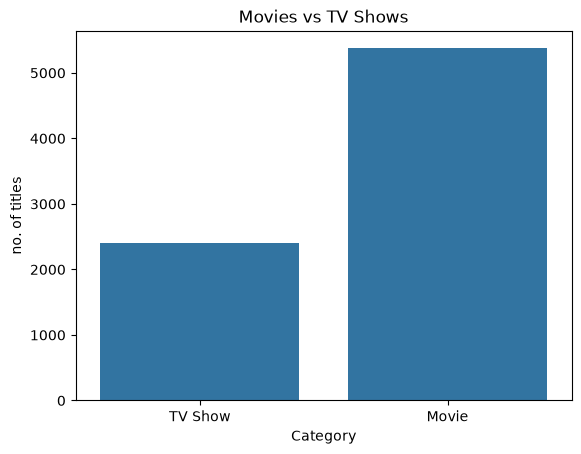

In [47]:
sns.countplot(data=df,x='Category')
plt.title('Movies vs TV Shows')
plt.xlabel('Category')
plt.ylabel('no. of titles')
plt.show()

In [51]:
original_dates = pd.read_csv("netflix_dataset.csv")['Release_Date']

In [52]:
df['Release_Date'] = pd.to_datetime(original_dates, errors='coerce')

### 6.3 Content Distribution by Release Year

In [54]:
df['Release_year']=df['Release_Date'].dt.year

In [55]:
df['Release_year'].value_counts().sort_index()

Release_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      24
2015.0      79
2016.0     432
2017.0    1201
2018.0    1660
2019.0    2134
2020.0    2004
2021.0     117
Name: count, dtype: int64

### 6.4 Year-wise Netflix Content Trend

In [56]:
yearly_counts= df['Release_year'].value_counts().sort_index()

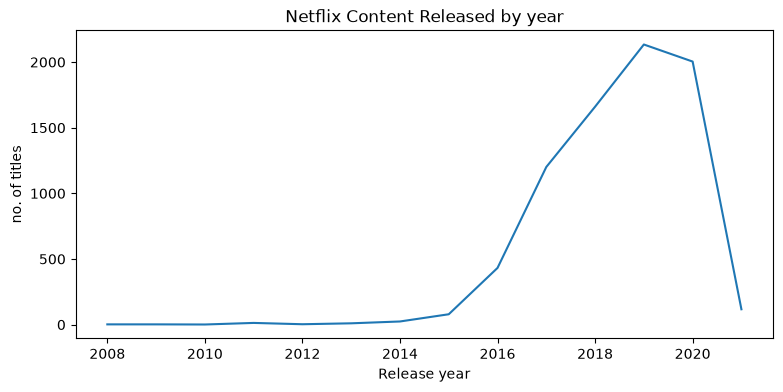

In [59]:
plt.figure(figsize=(9,4))
sns.lineplot( x= yearly_counts.index, y= yearly_counts.values)
plt.title('Netflix Content Released by year')
plt.xlabel('Release year')
plt.ylabel('no. of titles')
plt.show()

### 6.5 Movies vs TV Shows by Release Year

In [62]:
year_category = pd.crosstab(df['Release_year'], df['Category'])
year_category

Category,Movie,TV Show
Release_year,,
2008.0,2,0
2009.0,2,0
2010.0,1,0
2011.0,10,3
2012.0,2,1
2013.0,9,1
2014.0,19,5
2015.0,59,20
2016.0,298,134


### 6.6 Movies vs TV Shows by Release Year — Visualization

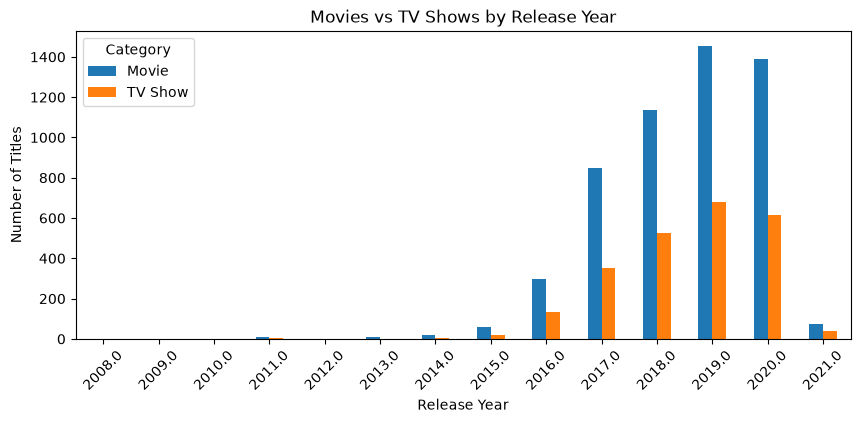

In [76]:
year_category.plot.bar(figsize=(10, 4))

plt.title('Movies vs TV Shows by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

### 6.7 Distribution of Content Ratings

In [64]:
df['Rating'].value_counts()

Rating
TV-MA       2863
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64

### 6.8 Content Ratings Distribution

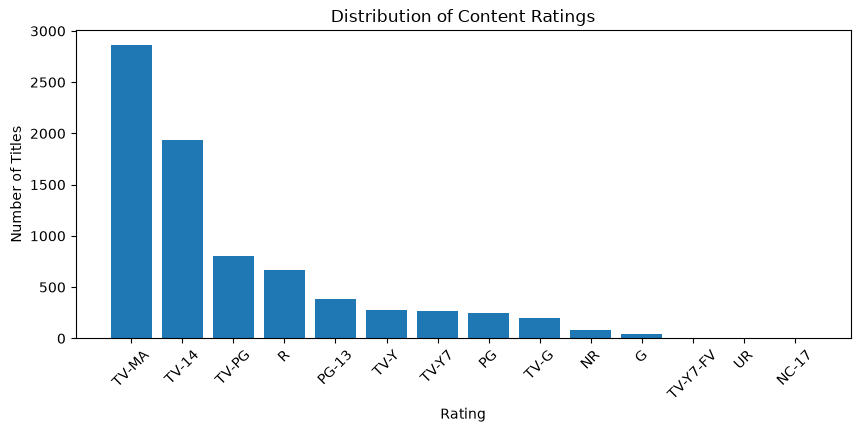

In [77]:
rating_counts = df['Rating'].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(rating_counts.index, rating_counts.values)

plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

### 6.9 Most Common Countries

In [66]:
df['Country'].head(10)

0           Brazil
1           Mexico
2        Singapore
3    United States
4    United States
5           Turkey
6            Egypt
7    United States
8            India
9            India
Name: Country, dtype: str

### 6.10 Splitting Multiple Countries

In [67]:
countries=df['Country'].str.split(', ')

In [69]:
countries.head()

0           [Brazil]
1           [Mexico]
2        [Singapore]
3    [United States]
4    [United States]
Name: Country, dtype: object

### 6.11 Counting Titles by Country

In [70]:
country_list = countries.explode()

In [71]:
country_list.value_counts()

Country
United States      3293
India               990
United Kingdom      722
not mentioned       506
Canada              412
                   ... 
Panama                1
United Kingdom,       1
Uganda                1
East Germany          1
Montenegro            1
Name: count, Length: 122, dtype: int64

### 6.12 Cleaning Country Names

In [72]:
df['Country'] = df['Country'].str.strip(', ')

In [73]:
countries = df['Country'].str.split(', ')
country_list = countries.explode()

In [74]:
country_list.value_counts()

Country
United States     3294
India              990
United Kingdom     723
not mentioned      506
Canada             412
                  ... 
Sudan                1
Panama               1
Uganda               1
East Germany         1
Montenegro           1
Name: count, Length: 118, dtype: int64

### 6.13 Top 10 Countries by Number of Titles

In [75]:
country_counts = country_list.value_counts()

country_counts.head(10)

Country
United States     3294
India              990
United Kingdom     723
not mentioned      506
Canada             412
France             349
Japan              286
Spain              215
South Korea        212
Germany            199
Name: count, dtype: int64

### 6.14 Top 10 Countries by Number of Titles

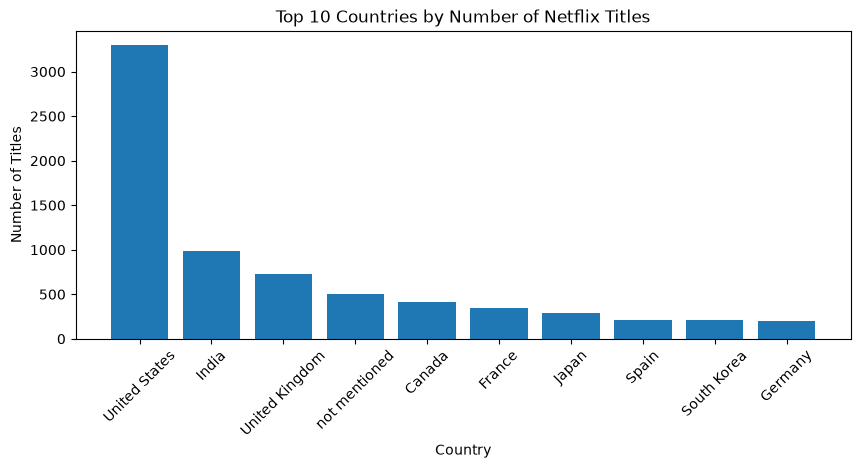

In [79]:
top_10_countries = country_counts.head(10)

plt.figure(figsize=(10, 4))
plt.bar(top_10_countries.index, top_10_countries.values)

plt.title('Top 10 Countries by Number of Netflix Titles')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

### 6.15 Content Duration

In [80]:
df['Duration'].value_counts().head(10)

Duration
1 Season     1606
2 Seasons     382
3 Seasons     184
90 min        136
93 min        131
91 min        125
94 min        125
95 min        119
92 min        118
97 min        117
Name: count, dtype: int64

### 6.16 Duration by Category

In [82]:
df.groupby('Category')['Duration'].value_counts().head(20)

Category  Duration
Movie     90 min      136
          93 min      131
          94 min      125
          91 min      125
          95 min      119
          92 min      118
          97 min      117
          96 min      115
          98 min      106
          103 min     101
          99 min      101
          88 min      101
          102 min      98
          106 min      97
          100 min      97
          101 min      96
          86 min       93
          105 min      91
          104 min      89
          89 min       88
Name: count, dtype: int64

### 6.17 TV Show Duration

In [84]:
df[df['Category']=='TV Show']['Duration'].value_counts()

Duration
1 Season      1606
2 Seasons      382
3 Seasons      184
4 Seasons       87
5 Seasons       58
6 Seasons       30
7 Seasons       19
8 Seasons       18
9 Seasons        8
10 Seasons       6
11 Seasons       3
13 Seasons       2
12 Seasons       2
15 Seasons       2
16 Seasons       1
Name: count, dtype: int64

### 6.18 Movie Duration in Minutes

In [ ]:
df['Movie_Duration'] = df['Duration'].str.extract('(\d+)').astype(float)

In [88]:
df[df['Category']=='Movie'][['Duration','Movie_Duration']].head()

,Duration,Movie_Duration
1,93 min,93.0
2,78 min,78.0
3,80 min,80.0
4,123 min,123.0
6,95 min,95.0


### 6.19 Average Movie Duration

In [89]:
df[df['Category']=='Movie']['Movie_Duration'].mean()

np.float64(99.33041697691735)

### 6.20 Distribution of Movie Durations

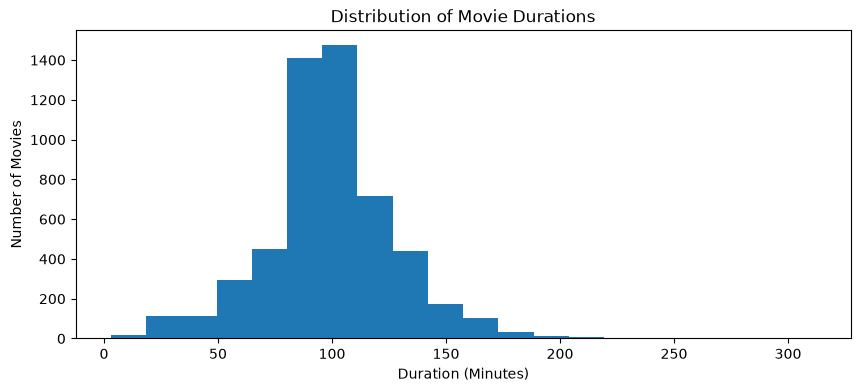

In [91]:
plt.figure(figsize=(10, 4))

plt.hist(df[df['Category'] == 'Movie']['Movie_Duration'], bins=20)

plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

plt.show()

### 6.21 Minimum and Maximum Movie Duration

In [92]:
movie_duration = df[df['Category'] == 'Movie']['Movie_Duration']

movie_duration.min(), movie_duration.max()

(np.float64(3.0), np.float64(312.0))

### 6.22 Number of Seasons in TV Shows


In [ ]:
df['Seasons']= df['Duration'].str.extract('(\d+)').astype(float)

In [94]:
df[df['Category']=='TV Show'][['Duration', 'Seasons']].head()

,Duration,Seasons
0,4 Seasons,4.0
5,1 Season,1.0
11,1 Season,1.0
12,1 Season,1.0
16,1 Season,1.0


### 6.23 Distribution of TV Shows by Number of Seasons

In [95]:
tv_season_counts = df[df['Category'] == 'TV Show']['Seasons'].value_counts().sort_index()
tv_season_counts

Seasons
1.0     1606
2.0      382
3.0      184
4.0       87
5.0       58
6.0       30
7.0       19
8.0       18
9.0        8
10.0       6
11.0       3
12.0       2
13.0       2
15.0       2
16.0       1
Name: count, dtype: int64

### 6.24 TV Shows by Number of Seasons

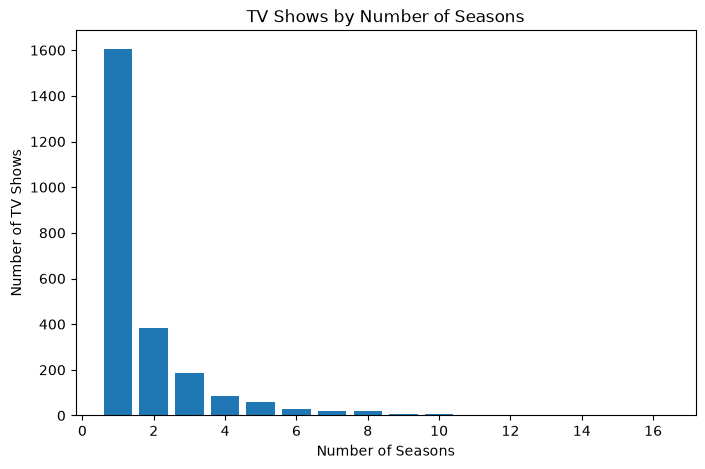

In [96]:
plt.figure(figsize=(8, 5))

plt.bar(tv_season_counts.index, tv_season_counts.values)

plt.title('TV Shows by Number of Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')

plt.show()

### 6.25 Maximum Number of Seasons

In [100]:
tv_shows = df[df['Category'] == 'TV Show'].copy()

tv_shows['Seasons'] = tv_shows['Duration'].str.extract(r'(\d+)').astype(float)

In [101]:
tv_shows['Seasons'].max()

np.float64(16.0)

### 6.26 TV Show with Maximum Seasons

In [102]:
tv_shows[tv_shows['Seasons'] == tv_shows['Seasons'].max()][['Title', 'Seasons']]

,Title,Seasons
2536,Grey's Anatomy,16.0


### 6.27 Ratings by Category

In [103]:
pd.crosstab(df['Category'], df['Rating'])

Rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
Category,,,,,,,,,,,,,,
Movie,39,3,79,247,386,663,1272,111,1845,505,117,95,5,5
TV Show,0,0,5,0,0,2,659,83,1018,301,163,176,1,0


### 6.28 Ratings by Category — Visualization

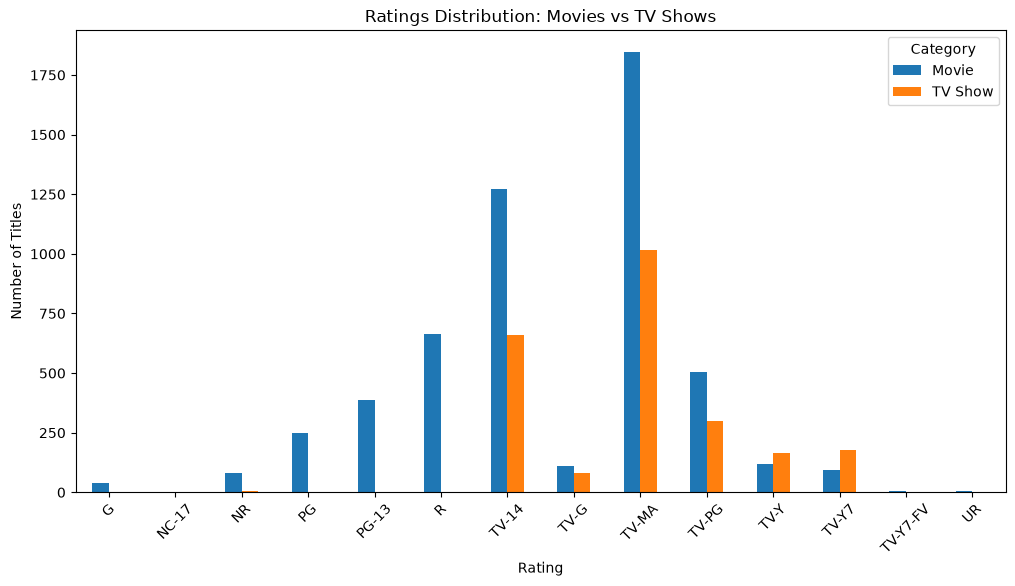

In [104]:
rating_category = pd.crosstab(df['Rating'], df['Category'])

rating_category.plot.bar(figsize=(12, 6))

plt.title('Ratings Distribution: Movies vs TV Shows')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.show()

### 6.29 Movies vs TV Shows Trend Over the Years


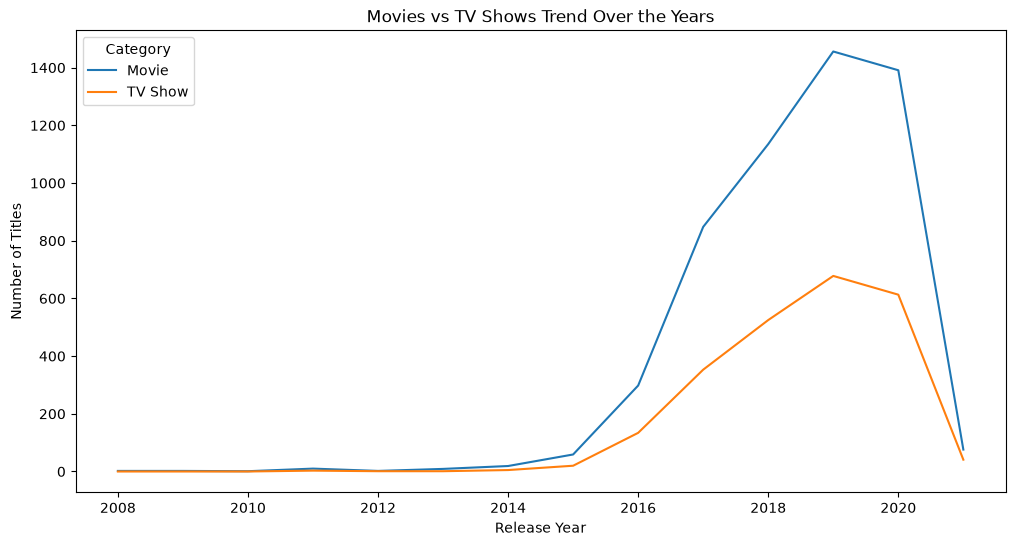

In [105]:
year_category.plot.line(figsize=(12, 6))

plt.title('Movies vs TV Shows Trend Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(title='Category')
plt.show()

### 6.30 Year with the Most Content

In [107]:
yearly_counts = df['Release_year'].value_counts()

yearly_counts.idxmax(), yearly_counts.max()

(np.float64(2019.0), np.int64(2134))

### 6.31 Top 10 Directors by Number of Titles

In [108]:
director_count=df[df['Director']!='unknown']['Director'].value_counts()

In [109]:
director_count.head(10)

Director
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          10
David Dhawan               9
Kunle Afolayan             8
Name: count, dtype: int64

### 6.32 Top 10 Directors by Number of Titles

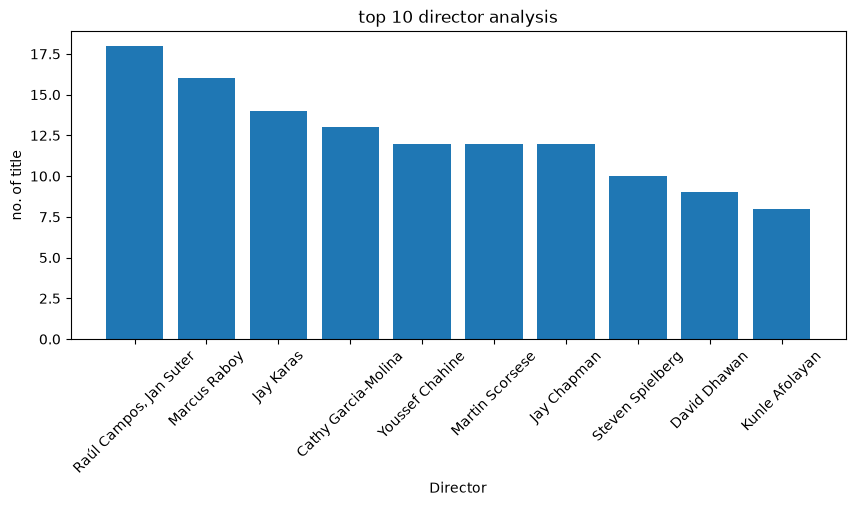

In [112]:
top_directors = director_count.head(10)
plt.figure(figsize=(10,4))
plt.bar(x=top_directors.index, height= top_directors.values)
plt.title('top 10 director analysis')
plt.xlabel('Director')
plt.ylabel('no. of title')
plt.xticks(rotation=45)
plt.show()

### 6.33 Most Frequent Cast Members

In [113]:
cast=df['Cast'].str.split(', ')

In [114]:
castlist= cast.explode()

In [117]:
castmembers= castlist[castlist !='unknown'].value_counts()
castmembers.head(10)

Cast
Anupam Kher         42
Shah Rukh Khan      35
Naseeruddin Shah    30
Om Puri             30
Takahiro Sakurai    29
Akshay Kumar        29
Boman Irani         27
Amitabh Bachchan    27
Paresh Rawal        27
Yuki Kaji           27
Name: count, dtype: int64

### 6.34 Top 10 Cast Members by Number of Titles

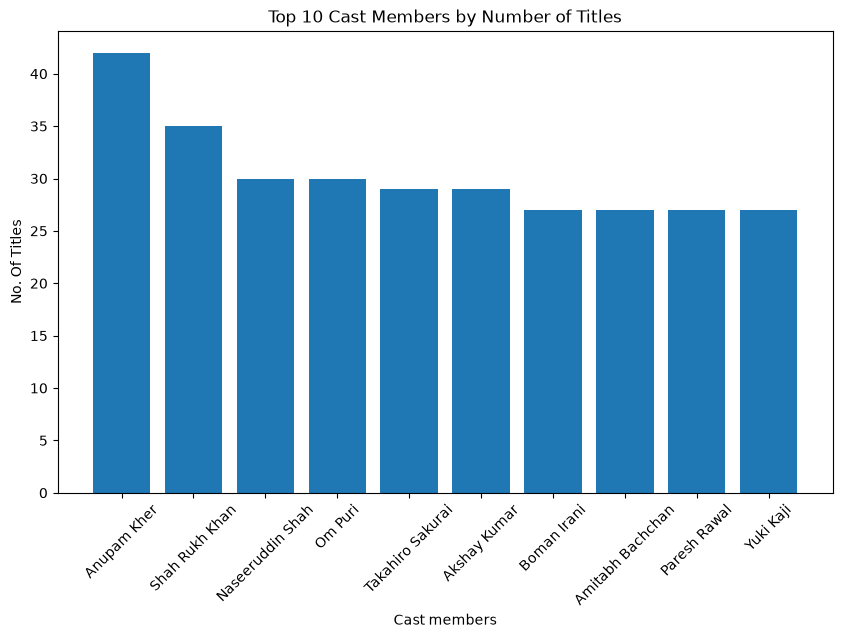

In [118]:
casting= castmembers.head(10)
plt.figure(figsize=(10,6))
plt.bar(casting.index, casting.values)
plt.title('Top 10 Cast Members by Number of Titles')
plt.xlabel('Cast members')
plt.ylabel('No. Of Titles')
plt.xticks(rotation=45)
plt.show()

### 6.35 Movies vs TV Shows by Country

In [129]:
countrycross= df[['Country','Category']].copy()
countrycross['Country']= countrycross['Country'].str.split(', ')
countrycross= countrycross.explode('Country').reset_index(drop=True)

countrycrosstab= pd.crosstab(countrycross['Country'],countrycross['Category'])
countrycrosstab.head(10)


Category,Movie,TV Show
Country,,
Afghanistan,1,0
Albania,1,0
Algeria,2,0
Angola,1,0
Argentina,64,18
Armenia,1,0
Australia,84,59
Austria,10,1
Azerbaijan,0,1


### 6.36 Top 10 Countries by Total Content

In [130]:
top_countries = countrycrosstab.sum(axis=1).sort_values(ascending=False).head(10)

In [131]:
countrycrosstab.loc[top_countries.index]

Category,Movie,TV Show
Country,,
United States,2428,866
India,915,75
United Kingdom,467,256
not mentioned,229,277
Canada,286,126
France,265,84
Japan,103,183
Spain,158,57
South Korea,55,157


### 6.37 Top 10 Countries — Movies vs TV Shows

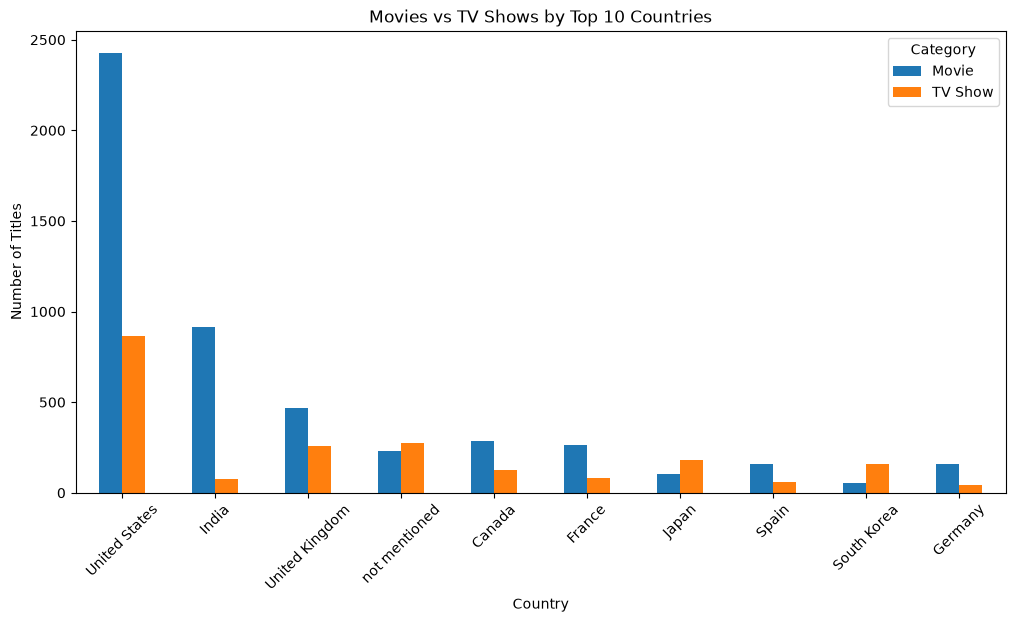

In [132]:
top_country_data = countrycrosstab.loc[top_countries.index]

top_country_data.plot.bar(figsize=(12, 6))

plt.title('Movies vs TV Shows by Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Category')

plt.show()

### 6.38 Most Common Ratings

In [136]:
rating_counts = df['Rating'].value_counts()

rating_counts.head(10)

Rating
TV-MA    2863
TV-14    1931
TV-PG     806
R         665
PG-13     386
TV-Y      280
TV-Y7     271
PG        247
TV-G      194
NR         84
Name: count, dtype: int64

## Final Insights

- The dataset contains **5,372 Movies** and **2,408 TV Shows**, showing that Movies are more common than TV Shows.
- The **United States** has the highest number of titles in the dataset, making it the largest content-producing country.
- **India** has significantly more Movies (**915**) than TV Shows (**75**).
- **Japan** has more TV Shows (**183**) than Movies (**103**).
- **South Korea** also has more TV Shows (**157**) than Movies (**55**).
- The average duration of Movies is approximately **99.33 minutes**.
- The shortest Movie in the dataset is **3 minutes**, while the longest Movie is **312 minutes**.
- The maximum number of seasons among TV Shows is **16**.

## Conclusion

This exploratory data analysis of the Netflix dataset helped identify important patterns in Netflix's content library. The analysis showed that Movies are more prevalent than TV Shows, with the United States contributing the highest number of titles. Country-wise analysis also revealed differences in the distribution of Movies and TV Shows across countries. Movie duration analysis showed an average duration of approximately 99 minutes, while TV Show analysis revealed that some shows contain multiple seasons, with the maximum reaching 16 seasons.

Overall, the analysis provides a clear understanding of the type, distribution, duration, ratings, countries, directors, and cast members represented in the Netflix dataset.

## Project Summary

This project performs exploratory data analysis on a Netflix dataset using Python, Pandas, NumPy, Matplotlib, and Seaborn. The analysis focuses on understanding Netflix content distribution, release trends, ratings, countries, movie durations, TV show seasons, directors, and cast members.